In [1]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import List, Callable

from gridops import set_up_grid_axis, GridAxis1D
from gridops import create_anterpolation_function, make_restriction_function

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 6
order = p - 1

# Grid charge computation

In [3]:
length = 10.
h = 0.25
n_particles = 25

grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)

anterpolate = create_anterpolation_function(grid)
jitted_anterpolate = jax.jit(anterpolate)

In [4]:
rng = onp.random.default_rng(12345)
for _ in tqdm(range(100)):
    positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
    charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

    # Call to trigger compilation
    gridcharge, _, _ = jitted_anterpolate(positions, charges)
    # Second call
    gridcharge, _, _ = jitted_anterpolate(positions, charges)

    assert jnp.allclose(gridcharge.sum(), charges.sum())

100%|██████████| 100/100 [00:01<00:00, 97.18it/s]


In [5]:
gridcharge

Array([ 0.00000000e+00, -9.74385969e-04, -3.00482834e-02, -1.31820293e-02,
        3.62665080e-01,  3.16970442e-01,  3.35478400e-02,  6.96742203e-03,
        1.16463749e-01,  2.22269560e-01,  6.53650651e-02,  3.41608491e-02,
        3.24116282e-01,  3.83055399e-01, -2.24589127e-01, -2.81571727e-01,
       -1.00714639e-01, -1.07602574e-01, -1.72396938e-01, -3.42622242e-01,
       -2.58281334e-01, -5.73181077e-02, -2.60852059e-02, -5.50980494e-03,
       -3.45097604e-02, -1.95102980e-01, -1.61638538e-01, -1.79825266e-02,
       -5.34324843e-03, -8.32442669e-02, -4.00926797e-01, -4.47185450e-01,
        5.30419358e-02,  1.71079893e-01, -1.98852509e-01, -5.61167112e-01,
       -2.06042263e-01, -6.98828926e-03,  1.75784966e-02,  1.71083439e-01,
        2.43275165e-01,  3.29224032e-01,  5.01320355e-01,  1.65154815e-01,
        7.36281763e-03,  7.96656388e-07,  0.00000000e+00], dtype=float64)

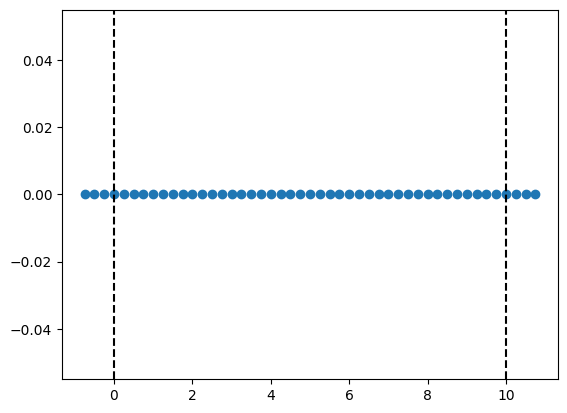

In [6]:
points = (onp.arange(grid.n_total) - p // 2) * grid.h

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
ax.scatter(points, onp.zeros_like(points))


In [7]:
# TODO: compute grid charge for a particle very close to upper domain bound -> I think the grid is currently too small in that case!

pos_appended = jnp.concatenate([positions, jnp.array([10.])])
charges_appended = jnp.concatenate([charges, jnp.array([0.6])])
gc, _, _ = anterpolate(pos_appended, charges_appended)

assert jnp.allclose(gc.sum(), charges_appended.sum())

In [8]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10.]))
gc

(Array([40, 41, 42, 43, 44, 45], dtype=int64),
 Array([0.        , 0.00833333, 0.21666667, 0.55      , 0.21666667,
        0.00833333], dtype=float64))

In [9]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10. - 1.e-6]))
gc

(Array([40, 41, 42, 43, 44, 45], dtype=int64),
 Array([8.53333330e-30, 8.33350000e-03, 2.16668333e-01, 5.50000000e-01,
        2.16665000e-01, 8.33316667e-03], dtype=float64))

In [10]:
int(onp.ceil(length / h))

40

In [11]:
grid.n_domain

41

In [12]:
grid.length, grid.h

(10.0, 0.25)

# Construction of grids

In [13]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [14]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=15, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fbbf7bfd040>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fbbf7bfd820>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=11, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fbbf7bfd790>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fbbf7bfd8b0>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=9, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fbbf7bfd550>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fbbf7bfd700>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=8, process_raw_indices=<fun

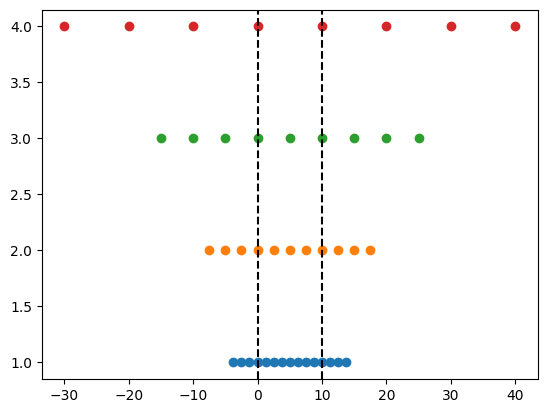

In [15]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [16]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [17]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [18]:
n_raw

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [19]:
onp.abs(n_raw - 2 * m_raw)

array([7, 6, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 6, 7])

In [20]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False])

In [21]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([ 4,  5,  6,  7,  8,  9, 10])

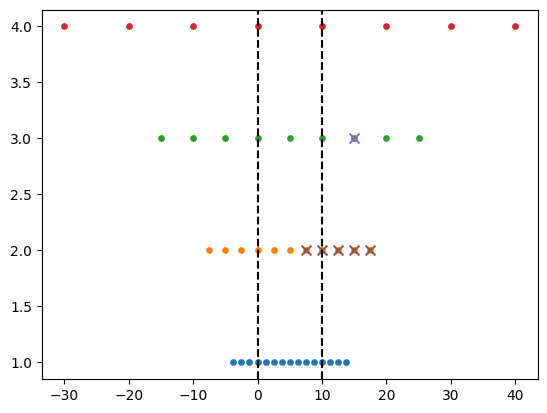

In [22]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [23]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [24]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

## Compare grid charges computed via restriction with directly computed ones

In [25]:
anterpolation_funcs_all_levels = [None] + [jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_function(grids_all_levels[l], grids_all_levels[l - 1], J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [26]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in anterpolation_funcs_all_levels[1:]]

gridcharges_via_restriction = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_direct[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [27]:
gridcharges_direct

[None,
 Array([ 0.00000000e+00,  7.99206745e-03,  2.38020789e-01,  9.45202429e-01,
         1.23204504e+00,  8.99210087e-01,  6.48432624e-01, -2.65156887e-02,
        -8.73304811e-03,  4.39864870e-01, -4.08880742e-01, -4.94877612e-01,
        -6.66595889e-02, -3.68572921e-04,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

In [28]:
gridcharges_via_restriction

[None,
 None,
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

In [29]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:], gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)

# Test jitting of anterpolation + loop over restriction at all grid levels in single function

In [30]:
def create_anterpolate_and_restrict(grids_all_levels, J: npt.ArrayLike) -> Callable:
    anterpolate = create_anterpolation_function(grids_all_levels[1])
    
    restriction_funcs_all_levels = [None, None]
    for lvl in range(2, len(grids_all_levels)):
        rf = make_restriction_function(grids_all_levels[lvl], grids_all_levels[lvl-1], J)
        restriction_funcs_all_levels.append(rf)
    
    def anterpolate_and_restrict(positions: jax.Array, charges: jax.Array) -> List:
        gridcharge_level_one, _, _ = anterpolate(positions_1d=positions, charges=charges)
        gridcharges_all_levels = [None, gridcharge_level_one]
        for lvl in range(2, len(grids_all_levels)):
            rf = restriction_funcs_all_levels[lvl]
            gc_lowergrid = gridcharges_all_levels[lvl - 1]
            gc = rf(gc_lowergrid)
            gridcharges_all_levels.append(gc)
        
        return gridcharges_all_levels
    
    return anterpolate_and_restrict

In [31]:
anterpolate_and_restrict = create_anterpolate_and_restrict(grids_all_levels, J)
jitted_anterpolate_and_restrict = jax.jit(anterpolate_and_restrict)

In [32]:
jitted_anterpolate_and_restrict(xs, qs)

[None,
 Array([ 0.00000000e+00,  7.99206745e-03,  2.38020789e-01,  9.45202429e-01,
         1.23204504e+00,  8.99210087e-01,  6.48432624e-01, -2.65156887e-02,
        -8.73304811e-03,  4.39864870e-01, -4.08880742e-01, -4.94877612e-01,
        -6.66595889e-02, -3.68572921e-04,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

# Prolongation

In [41]:
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [33]:
J_rolled = onp.roll(J, (len(J) - 1) // 2 + 1)

ns_raw = jnp.arange(-10, 15)
m_raw = 5

for m_raw in range(0, 10):
    m_minus_2n = m_raw - 2 * ns_raw
    cond = jnp.abs(m_minus_2n) <= p // 2
    print(m_raw, cond.sum(), m_minus_2n[cond], J_rolled[m_minus_2n[cond]])

0 3 [ 2  0 -2] [0.1875 0.625  0.1875]
1 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
2 3 [ 2  0 -2] [0.1875 0.625  0.1875]
3 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
4 3 [ 2  0 -2] [0.1875 0.625  0.1875]
5 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
6 3 [ 2  0 -2] [0.1875 0.625  0.1875]
7 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
8 3 [ 2  0 -2] [0.1875 0.625  0.1875]
9 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]


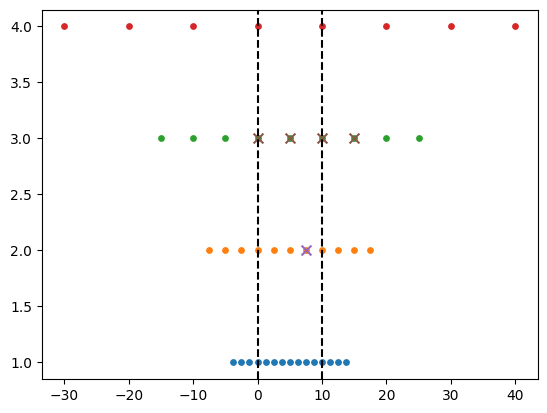

In [40]:
lvl = 2
m_raw = 3

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

ns_raw = shift(onp.arange(len(points_all_levels[lvl + 1])))
m_minus_2n = m_raw - 2 * ns_raw
cond = jnp.abs(m_minus_2n) <= p // 2
ns_raw_selected = ns_raw[cond]

ax.scatter(points_all_levels[lvl][unshift(m_raw)], lvl, marker="x", s=50)
ax.scatter(points_all_levels[lvl + 1][unshift(ns_raw_selected)],
           onp.full_like(ns_raw_selected, lvl + 1), marker="x", s=50)

In [35]:
print(J)

[0.03125 0.1875  0.46875 0.625   0.46875 0.1875  0.03125]


In [36]:
J_rolled = onp.roll(J, (len(J) - 1) // 2)
print(J_rolled)

[0.46875 0.1875  0.03125 0.03125 0.1875  0.46875 0.625  ]


In [37]:
J_rolled[0]

0.46875

In [38]:
J_rolled[1], J_rolled[-1]

(0.1875, 0.625)

In [39]:
J_rolled[2], J_rolled[-2]

(0.03125, 0.46875)